### Name    : Ahmed Anwar Mazhar
### ID      : 120210007
### Computer Vision Lab SIFT assignment

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Image Matching with SIFT + FLANN


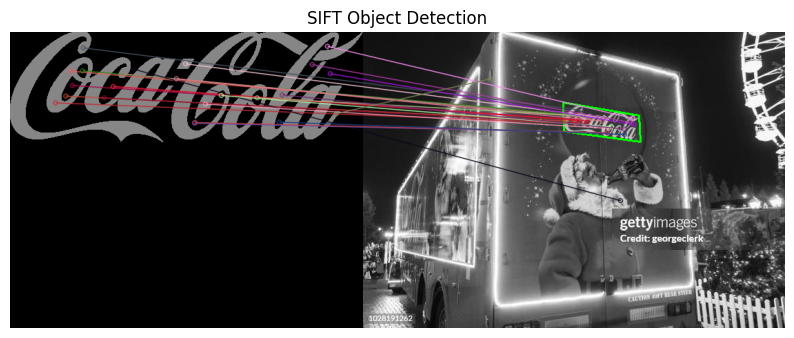

In [ ]:
# Initialize SIFT detector
sift = cv2.SIFT_create()

# Load images in grayscale to compute intensity gradients efficiently
query_img = cv2.imread(
    "/media/ahmed/Work/Materials/8th Sem/Computer Vision/Labs/SIFT/query.png",
    cv2.IMREAD_GRAYSCALE,
)
target_img = cv2.imread(
    "/media/ahmed/Work/Materials/8th Sem/Computer Vision/Labs/SIFT/target.jpg",
    cv2.IMREAD_GRAYSCALE,
)

# Detect keypoints and descriptors
kp1, des1 = sift.detectAndCompute(query_img, None)
kp2, des2 = sift.detectAndCompute(target_img, None)

# FLANN params
index_params = dict(algorithm=1, trees=5)  # KD_Tree with 5 trees
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

# Match descriptors
matches = flann.knnMatch(des1, des2, k=2)

# Lowe's ratio test
good_matches = [
    m for m, n in matches if m.distance < 0.75 * n.distance
]  # Match is only kept if its distance is less than 75% of the second-best match

if len(good_matches) >= 4:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    H, _ = cv2.findHomography(
        src_pts, dst_pts, cv2.RANSAC, 5.0
    )  # Maps the keypoints from the query image to the target image.

    if H is not None:
        h_q, w_q = query_img.shape
        corners = np.float32([[0, 0], [0, h_q], [w_q, h_q], [w_q, 0]]).reshape(-1, 1, 2)
        projected = cv2.perspectiveTransform(corners, H)

        # Draw the bounding box on the target image
        target_img_color = cv2.cvtColor(target_img, cv2.COLOR_GRAY2BGR)
        cv2.polylines(target_img_color, [np.int32(projected)], True, (0, 255, 0), 2)

        # Draw keypoint matches
        result_img = cv2.drawMatches(
            query_img,
            kp1,
            target_img_color,
            kp2,
            good_matches,
            None,
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        )

        # Convert BGR to RGB
        result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 8))
        plt.imshow(result_img_rgb)
        plt.title("SIFT Object Detection")
        plt.axis("off")
        plt.show()
    else:
        print("Homography could not be computed")
else:
    print("Not enough good matches")

### Bonus Part: SIFT with video detection


In [ ]:
# Video Detection
cap = cv2.VideoCapture(
    "/media/ahmed/Work/Materials/8th Sem/Computer Vision/Labs/SIFT/cocacola.mp4"
)

# Get the dimensions of the query image
h_q, w_q = query_img.shape

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Convert frame to grayscale
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # Detect keypoints and descriptors in the frame
    kp2, des2 = sift.detectAndCompute(gray_frame, None)

    if des2 is not None and len(des2) >= 2:
        # Match descriptors using FLANN
        matches = flann.knnMatch(des1, des2, k=2)
        
        # Apply Lowe's ratio test
        good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]

        if len(good_matches) >= 4:
            # Get the source and destination points for homography
            src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

            # Compute the homography matrix
            H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

            if H is not None:
                # Get the corners of the query image
                corners = np.float32([[0, 0], [0, h_q], [w_q, h_q], [w_q, 0]]).reshape(-1, 1, 2)
                
                # Apply the homography transformation to get the projected corners
                projected = cv2.perspectiveTransform(corners, H)

                # Draw bounding box around the detected object on the frame
                frame_color = frame.copy()
                cv2.polylines(frame_color, [np.int32(projected)], True, (0, 255, 0), 2)

                # Draw keypoint matches
                result_frame = cv2.drawMatches(
                    query_img, kp1, frame_color, kp2, good_matches, None,
                    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
                )

                # Display the result using OpenCV window
                cv2.imshow("SIFT Object Detection", result_frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
